In [3]:
# Bersihkan outlier (sisakan 20% data terakhir) dan interpolasi untuk setiap file CSV dalam folder input, lalu simpan hasilnya ke folder output.
import pandas as pd
import numpy as np
import glob
import os

# --- PATH CONFIGURATION ---
INPUT_DIR = "Source Code\\Plot Data\\Dirty Data"
OUTPUT_DIR = "Source Code\\Plot Data\\Clean Data"
PROTECTION_PERCENT = 0.20  # Protect the last 20% of rows
# ---------------------------

def cleanse_and_interpolate(df):
    """
    Performs IQR cleaning and interpolation on a dataframe.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = np.nan
        df[col] = df[col].interpolate(method='linear').ffill().bfill()
    return df

os.makedirs(OUTPUT_DIR, exist_ok=True)
files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))

for file_path in files:
    filename = os.path.basename(file_path)
    df = pd.read_csv(file_path)
    
    # Calculate the split point
    split_index = int(len(df) * (1 - PROTECTION_PERCENT))
    
    # Split the data
    to_clean = df.iloc[:split_index].copy()
    to_protect = df.iloc[split_index:].copy()
    
    # Clean only the first part
    cleaned_part = cleanse_and_interpolate(to_clean)
    
    # Combine them back together
    final_df = pd.concat([cleaned_part, to_protect], axis=0)
    
    # Save
    save_path = os.path.join(OUTPUT_DIR, filename)
    final_df.to_csv(save_path, index=False)
    
    print(f"Processed: {filename} (Cleaned first {100-int(PROTECTION_PERCENT*100)}%)")

print("All files processed")

All files processed


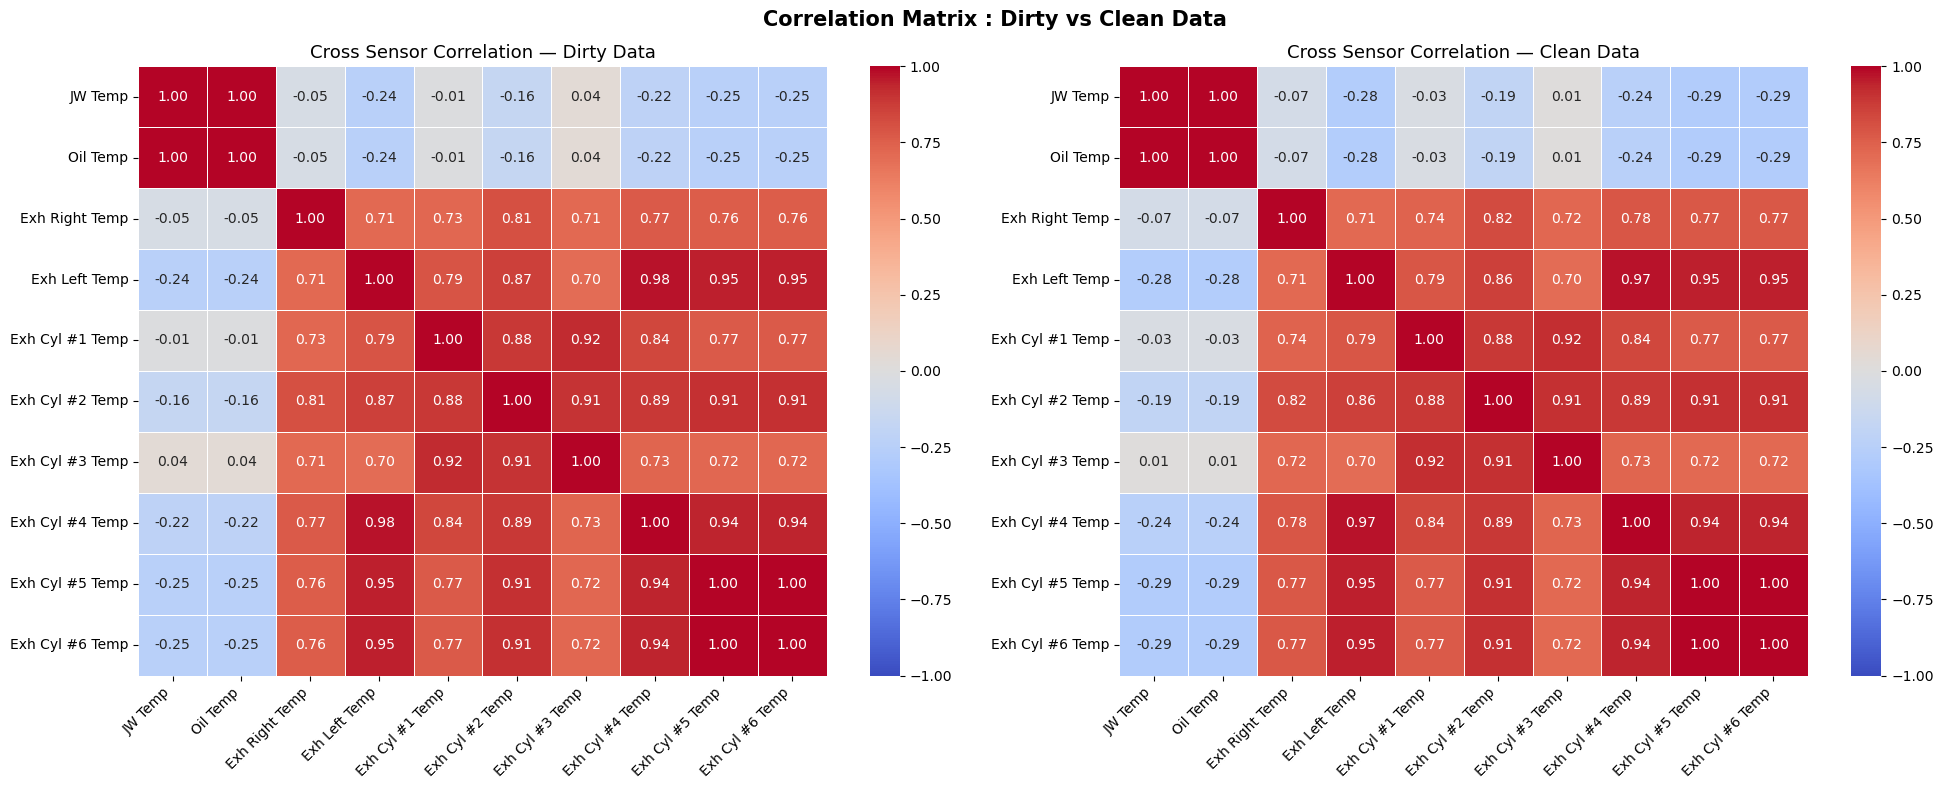

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DIRTY_DIR = "Dirty Data"
CLEAN_DIR = "Clean Data"
RUN_COUNT = 7

def load_and_combine(directory):
    dfs = []
    for i in range(1, RUN_COUNT + 1):
        path = os.path.join(directory, f'run_to_failure{i}_pad.csv')
        if not os.path.exists(path):
            print(f"Skip: {path}")
            continue
        dfs.append(pd.read_csv(path))
    if not dfs:
        raise FileNotFoundError(f"Tidak ada file CSV di {directory}")
    return pd.concat(dfs, ignore_index=True)

dirty_data = load_and_combine(DIRTY_DIR).select_dtypes(include=["number"])
clean_data = load_and_combine(CLEAN_DIR).select_dtypes(include=["number"])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, data, title in zip(axes,
                            [dirty_data, clean_data],
                            ["Dirty Data", "Clean Data"]):
    corr = data.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1,
                linewidths=0.5, ax=ax)
    ax.set_title(f"Cross Sensor Correlation — {title}", fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle("Correlation Matrix : Dirty vs Clean Data", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

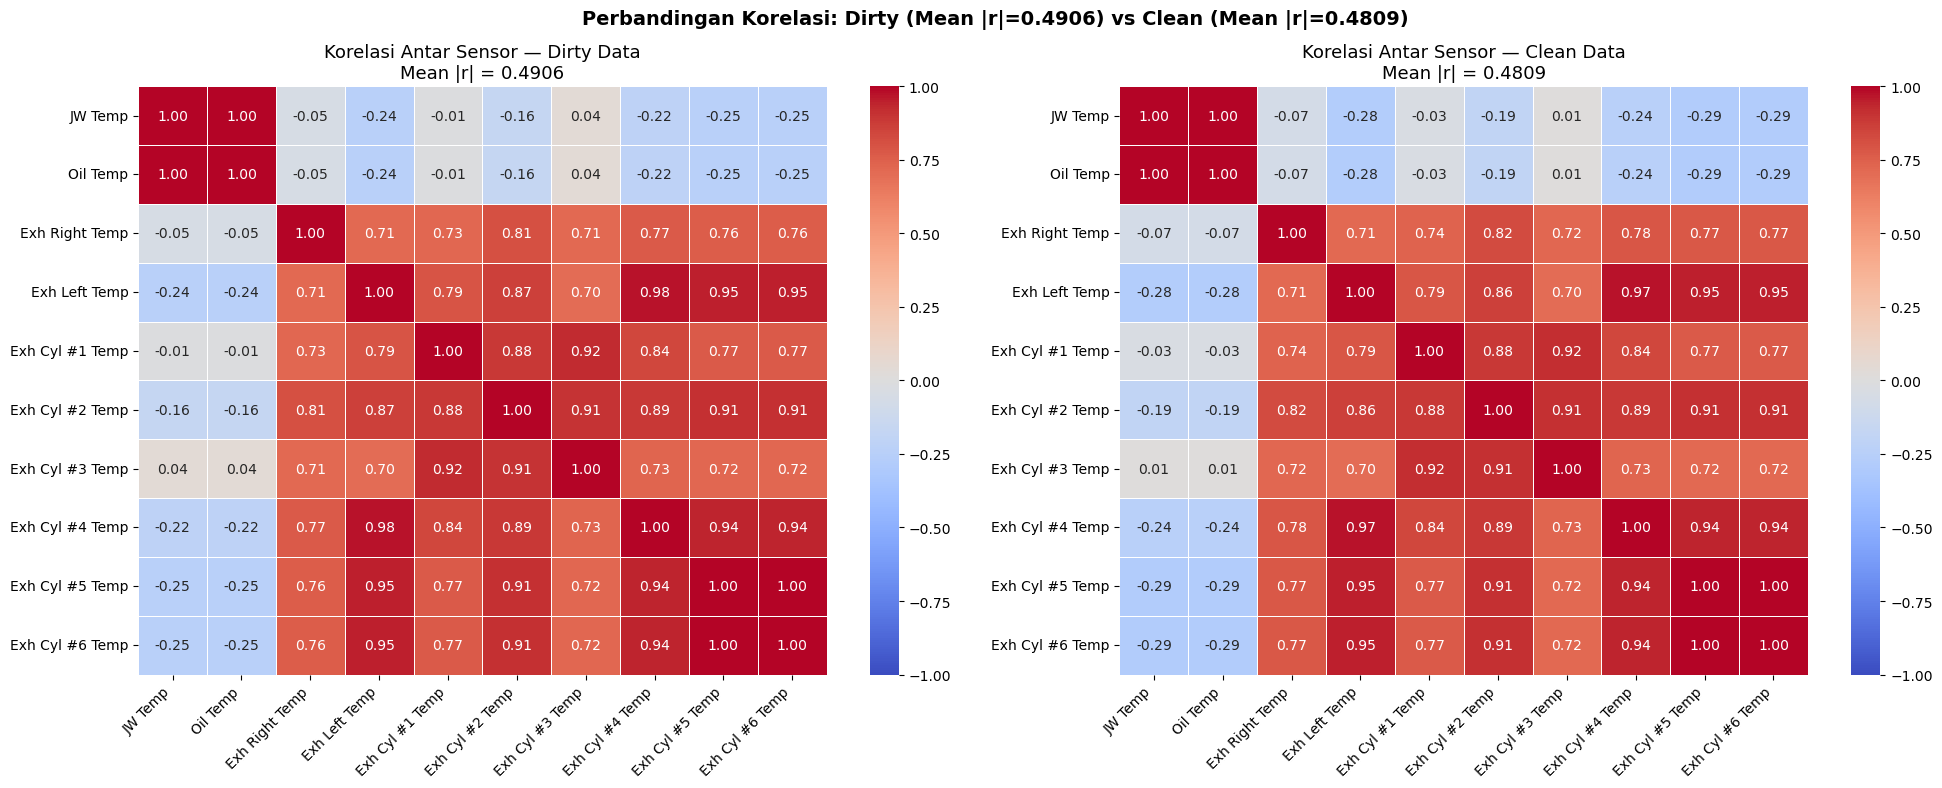

Mean Absolute Correlation — Dirty : 0.4906
Mean Absolute Correlation — Clean : 0.4809
Selisih                           : 0.0097


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np

DIRTY_DIR = "Dirty Data"
CLEAN_DIR = "Clean Data"

def load_and_combine(directory):
    files = sorted(glob.glob(os.path.join(directory, "*.csv")))
    if not files:
        raise FileNotFoundError(f"Tidak ada file CSV di {directory}")
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

dirty_data = load_and_combine(DIRTY_DIR).select_dtypes(include=["number"])
clean_data = load_and_combine(CLEAN_DIR).select_dtypes(include=["number"])

dirty_corr = dirty_data.corr()
clean_corr = clean_data.corr()

# Skor keseluruhan — rata-rata absolute korelasi (exclude diagonal)
def mean_abs_corr(corr_matrix):
    mask = ~np.eye(len(corr_matrix), dtype=bool)  # exclude diagonal (self-correlation = 1)
    return corr_matrix.values[mask].mean()

dirty_score = mean_abs_corr(dirty_corr)
clean_score = mean_abs_corr(clean_corr)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, corr, title, score in zip(axes,
                                   [dirty_corr, clean_corr],
                                   ["Dirty Data", "Clean Data"],
                                   [dirty_score, clean_score]):
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1,
                linewidths=0.5, ax=ax)
    ax.set_title(f"Korelasi Antar Sensor — {title}\nMean |r| = {score:.4f}", fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle(
    f"Perbandingan Korelasi: Dirty (Mean |r|={dirty_score:.4f}) vs Clean (Mean |r|={clean_score:.4f})",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"Mean Absolute Correlation — Dirty : {dirty_score:.4f}")
print(f"Mean Absolute Correlation — Clean : {clean_score:.4f}")
print(f"Selisih                           : {abs(clean_score - dirty_score):.4f}")

Memproses run_to_failure1_pad.csv...


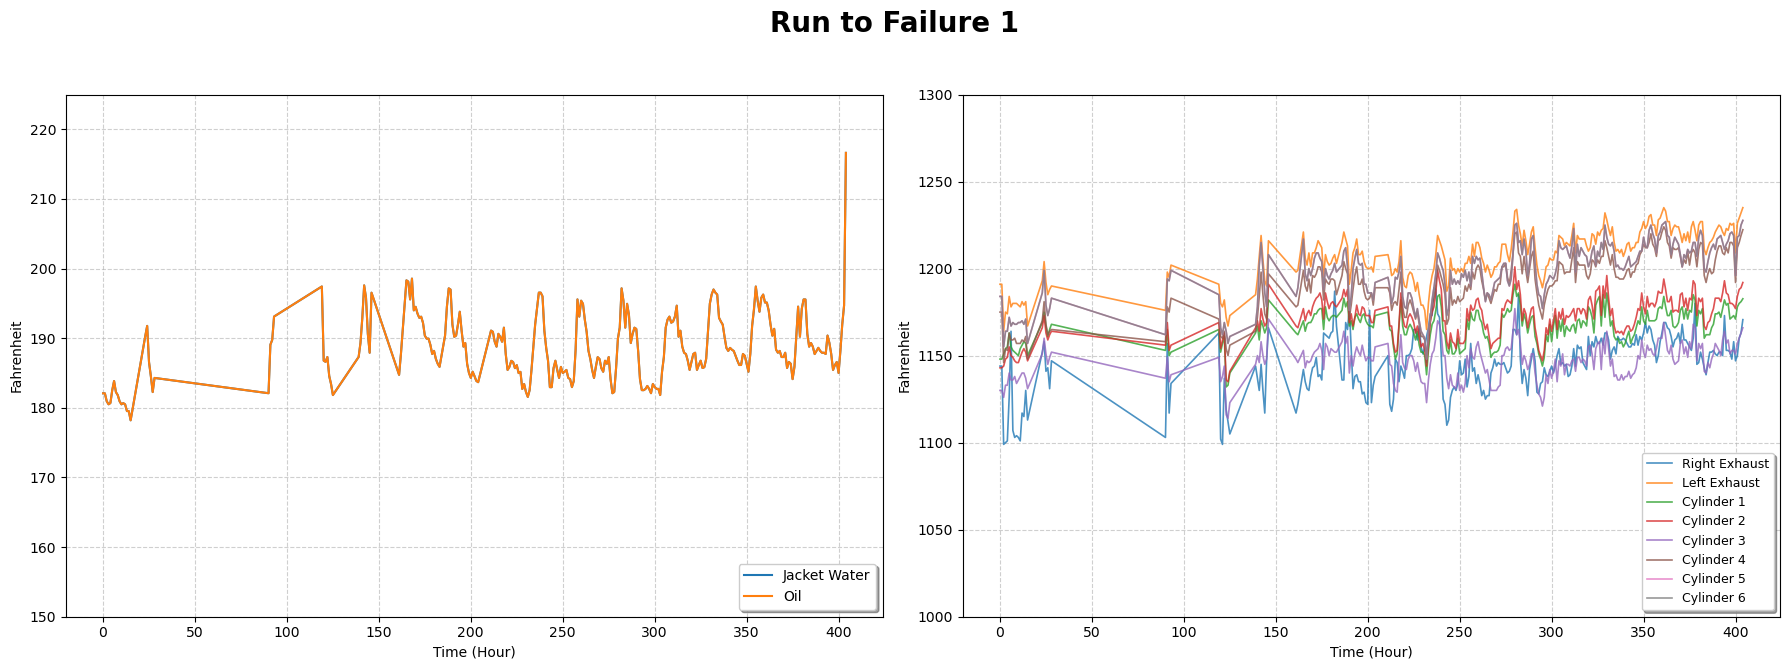

Memproses run_to_failure2_pad.csv...


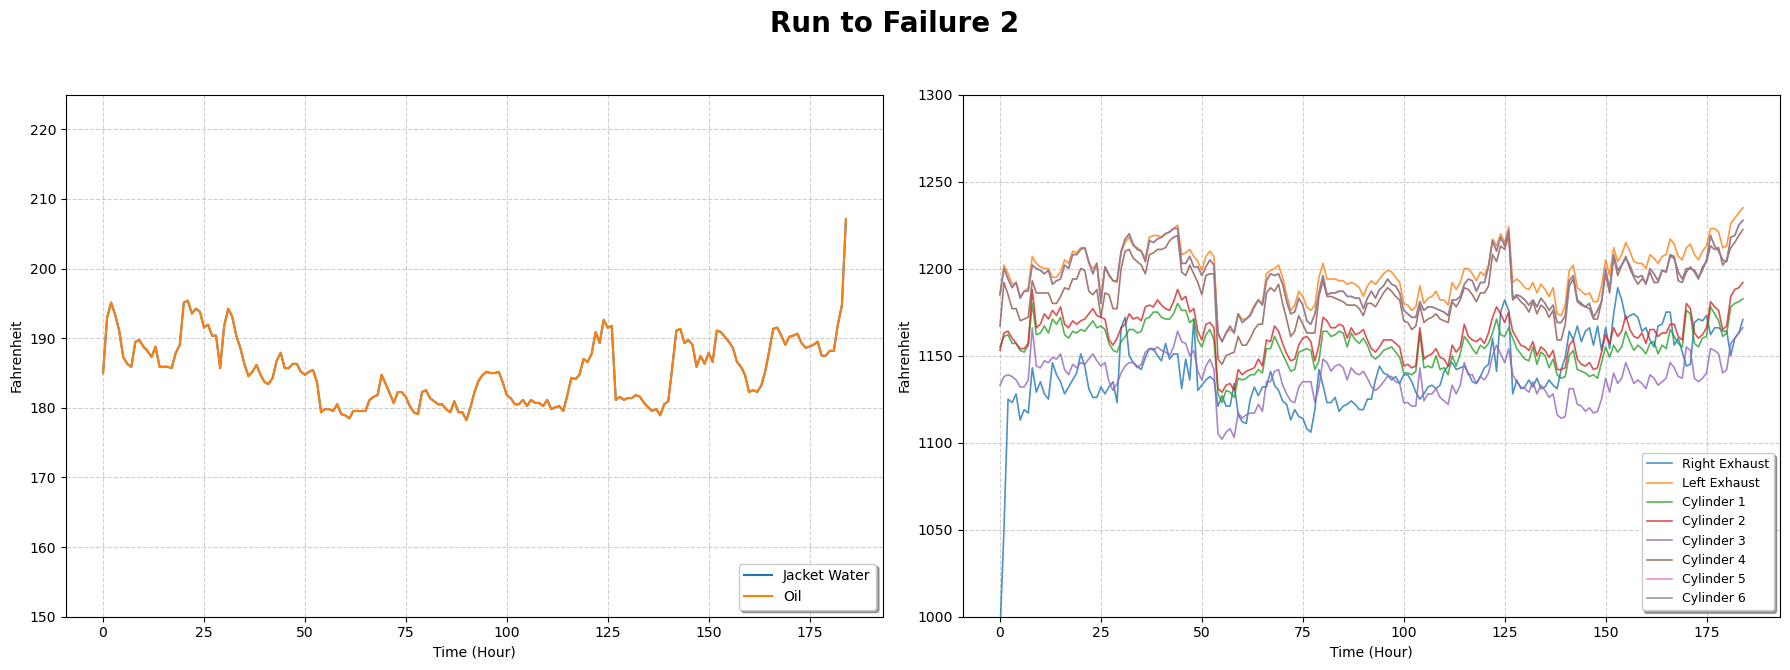

Memproses run_to_failure3_pad.csv...


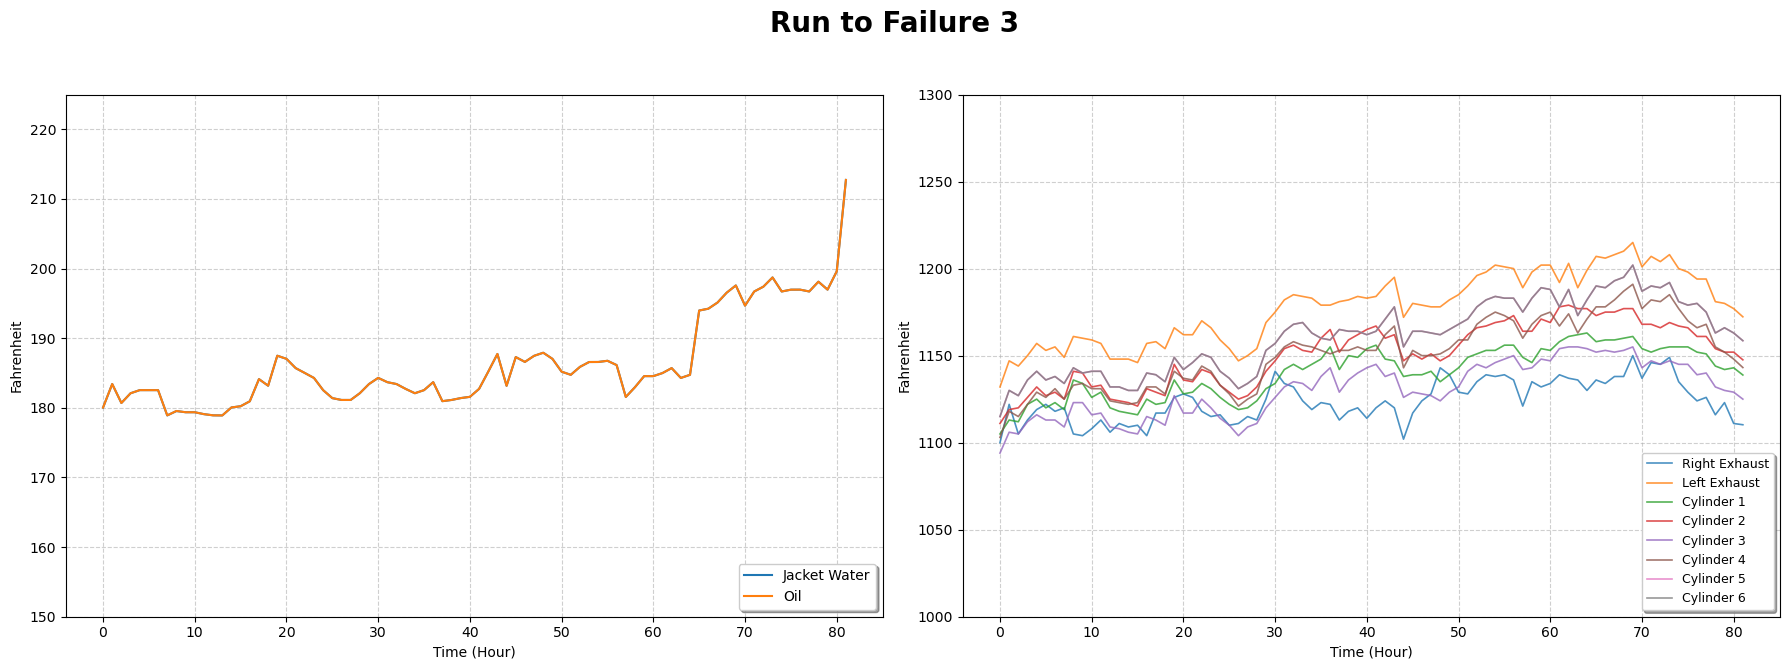

Memproses run_to_failure4_pad.csv...


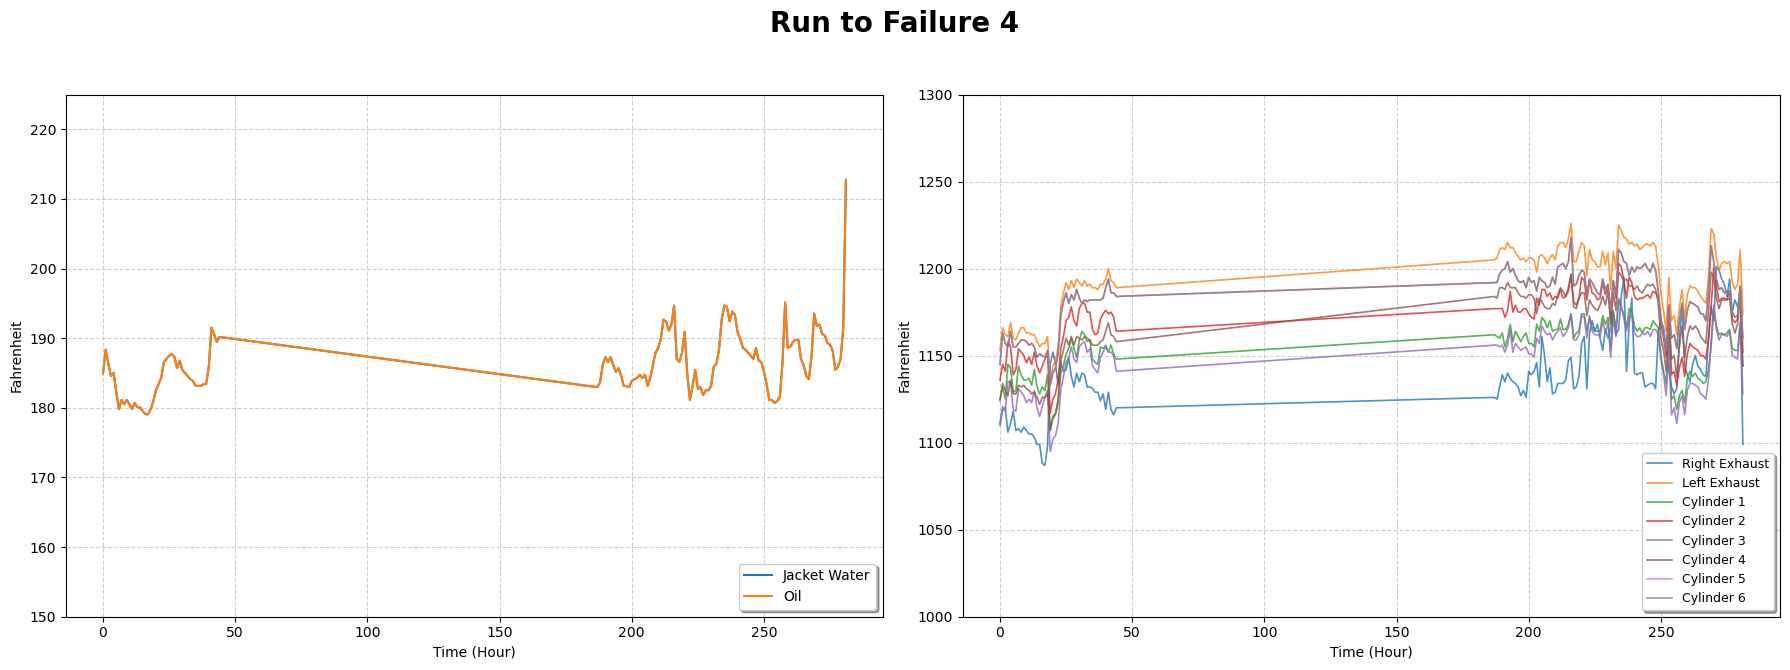

Memproses run_to_failure5_pad.csv...


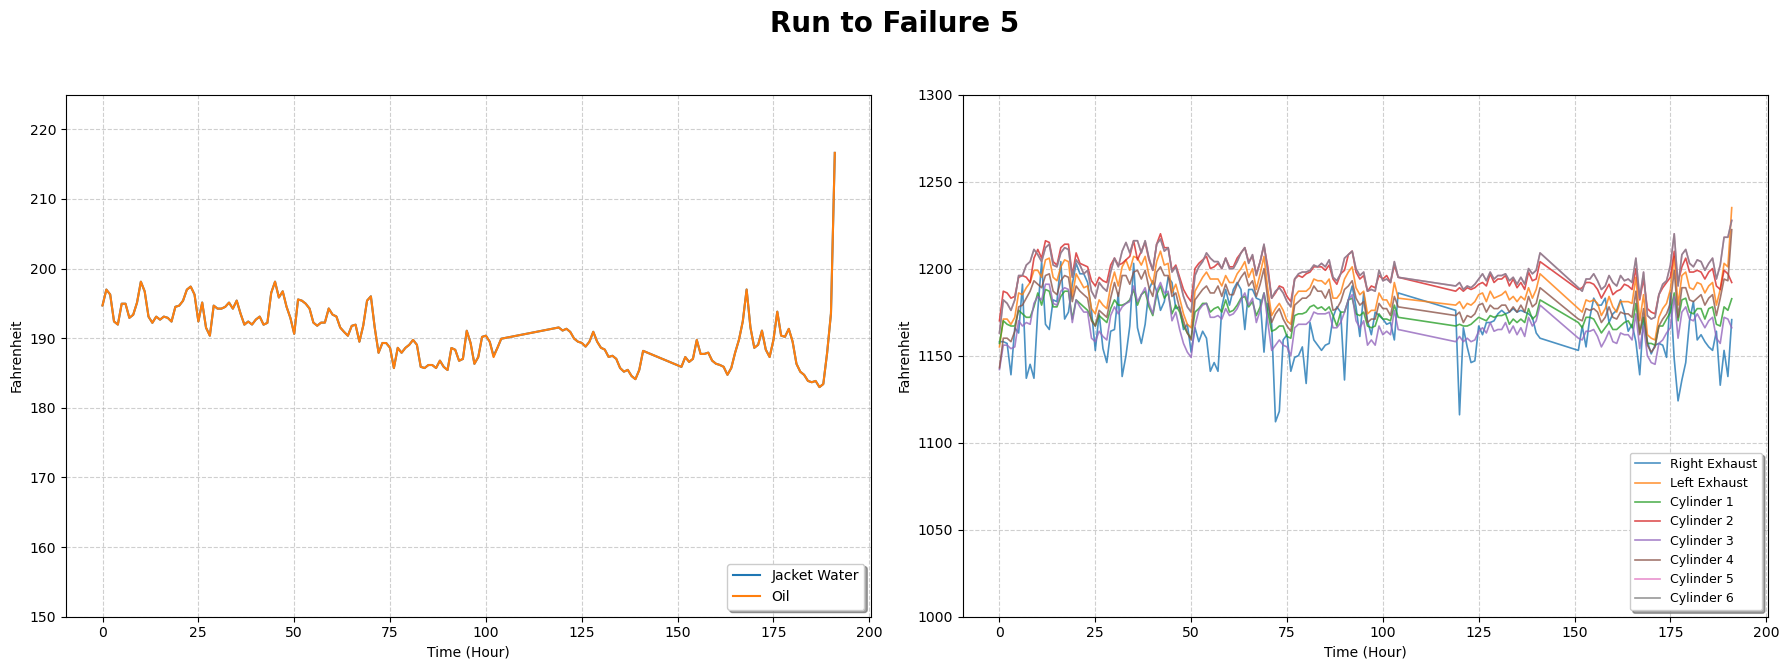

Memproses run_to_failure6_pad.csv...


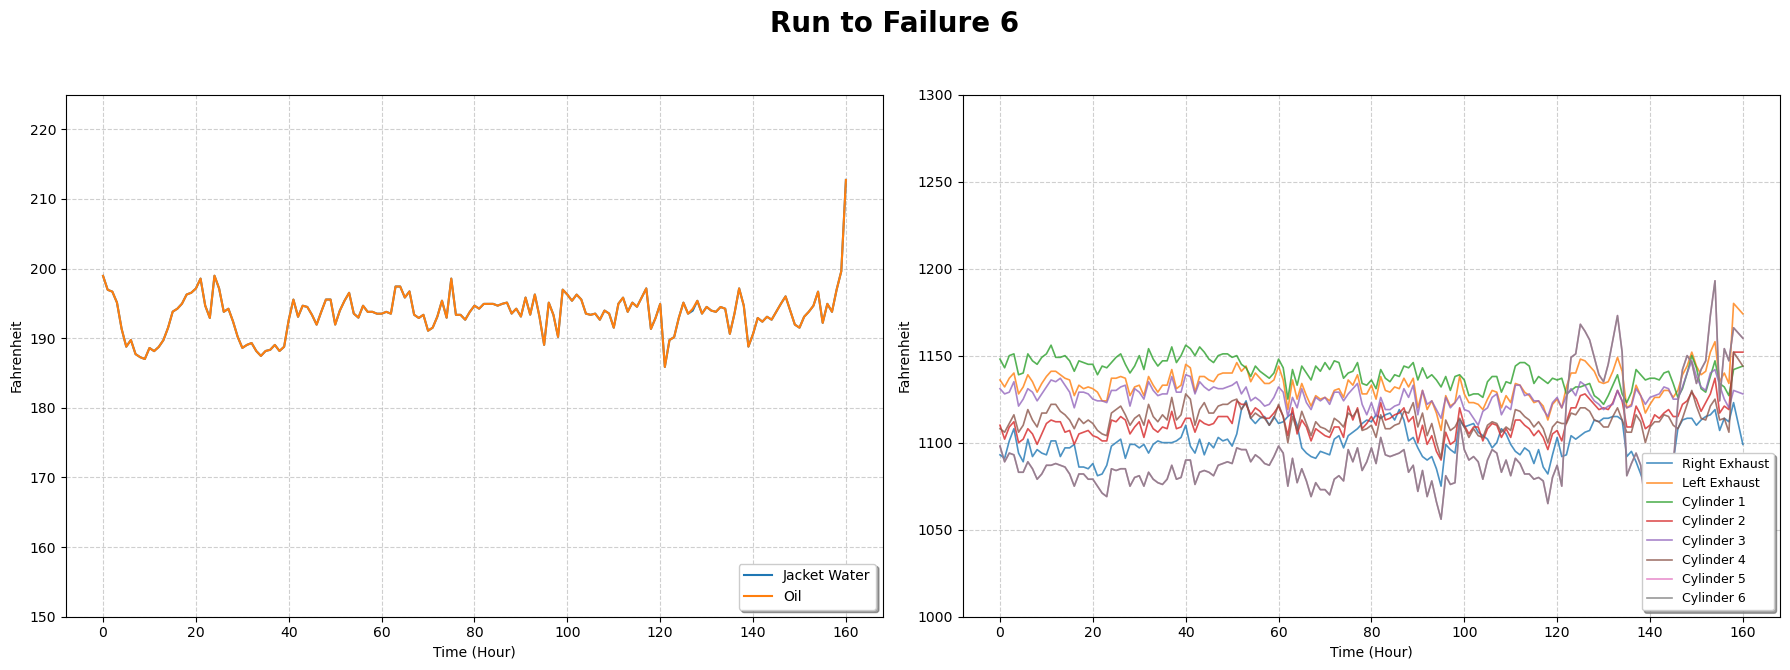

Memproses run_to_failure7_pad.csv...


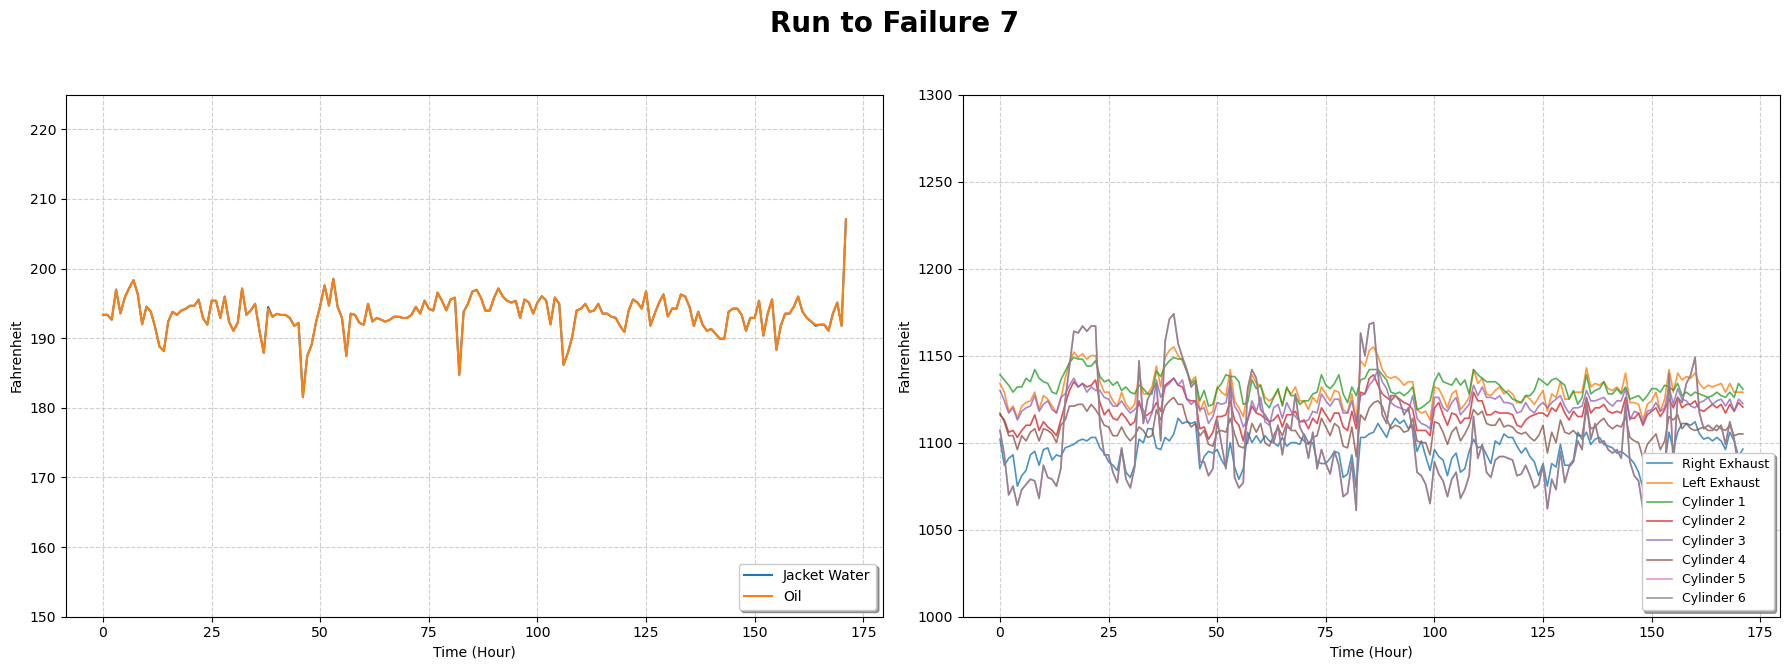

In [10]:
# %% Plot Combined Engineering Data
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

def plot_combined_data(file_dir, file_name):
    FILE_PATH = os.path.join(file_dir, file_name)
    
    # --- CONFIGURATION ---
    NON_EXHAUST_SERIES = {
        "JW Temp": "Jacket Water",
        "Oil Temp": "Oil",
    }
    
    EXHAUST_SERIES = {
        "Exh Right Temp": "Right Exhaust",
        "Exh Left Temp": "Left Exhaust",
        "Exh Cyl #1 Temp": "Cylinder 1",
        "Exh Cyl #2 Temp": "Cylinder 2",
        "Exh Cyl #3 Temp": "Cylinder 3",
        "Exh Cyl #4 Temp": "Cylinder 4",
        "Exh Cyl #5 Temp": "Cylinder 5",
        "Exh Cyl #6 Temp": "Cylinder 6",
    }

    # Limits
    Y_LIMITS_NON = (150, 225)
    Y_LIMITS_EXH = (1000, 1300)
    
    # Ekstraksi Nomor File
    match = re.search(r'\d+', file_name)
    file_number = match.group() if match else "X"

    # Load Data
    if not os.path.exists(FILE_PATH):
        print(f"Error: File {FILE_PATH} tidak ditemukan.")
        return
    
    df = pd.read_csv(FILE_PATH)

    # --- SETUP PLOT (1 Row, 2 Columns) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"Run to Failure {file_number}", fontsize=20, fontweight='bold')

    # 1. Plot Non-Exhaust (Kiri)
    for col, label in NON_EXHAUST_SERIES.items():
        if col in df.columns:
            ax1.plot(df.index, df[col], label=label, linewidth=1.5)
    
    ax1.set_ylabel("Fahrenheit")
    ax1.set_xlabel("Time (Hour)")
    ax1.set_ylim(Y_LIMITS_NON)
    ax1.grid(True, linestyle='--', alpha=0.6)
    # Legend di dalam box, kanan bawah
    ax1.legend(loc='lower right', frameon=True, shadow=True, facecolor='white')

    # 2. Plot Exhaust (Kanan)
    for col, label in EXHAUST_SERIES.items():
        if col in df.columns:
            ax2.plot(df.index, df[col], label=label, linewidth=1.2, alpha=0.8)
    
    ax2.set_ylabel("Fahrenheit")
    ax2.set_xlabel("Time (Hour)")
    ax2.set_ylim(Y_LIMITS_EXH)
    ax2.grid(True, linestyle='--', alpha=0.6)
    # Legend di dalam box, kanan bawah
    ax2.legend(loc='lower right', frameon=True, shadow=True, facecolor='white', fontsize=9)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Memberi ruang untuk suptitle
    plt.savefig(os.path.join(file_dir, f"{file_name[:-4]}.png"))
    plt.show()

# RUN
folder_path = r"Dirty Data"

for i in range(1, 8):
    target_file = f"run_to_failure{i}_pad.csv"
    print(f"Memproses {target_file}...")
    plot_combined_data(folder_path, target_file)

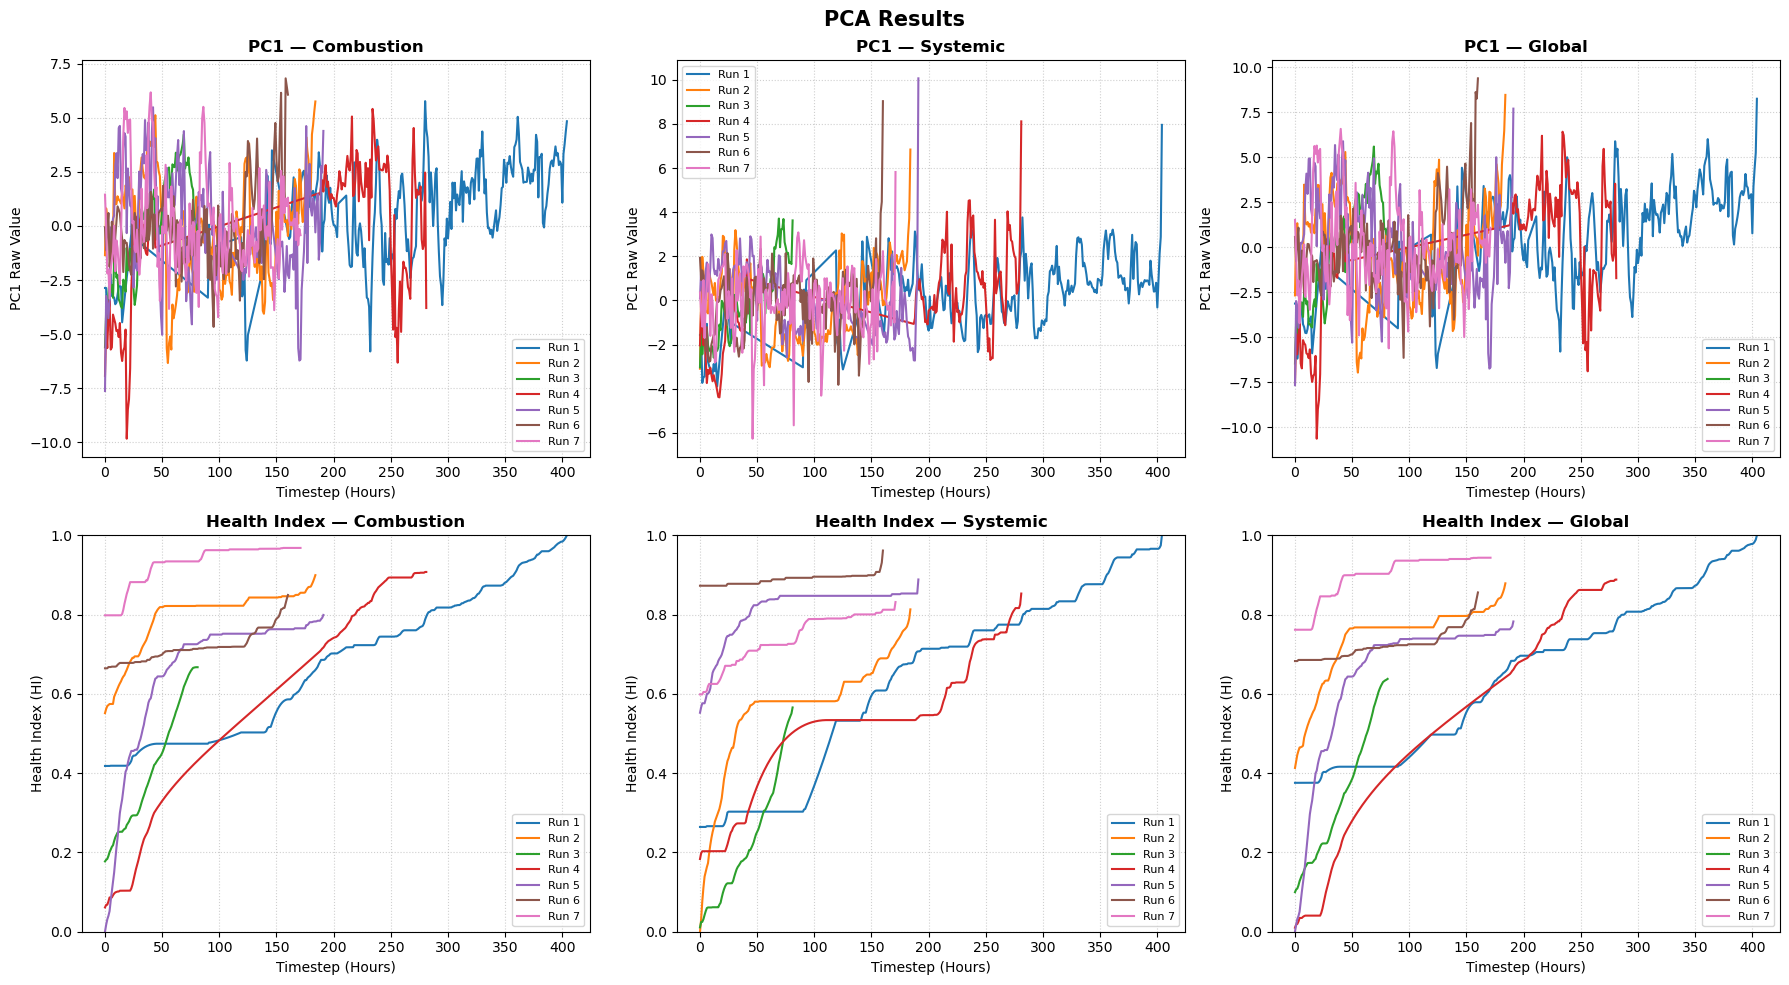

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR  = r"Dirty Data"
RUN_COUNT = 7

SCENARIOS = ['Combustion', 'Systemic', 'Global']
COLORS    = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# Load semua run
runs = {}
for i in range(1, RUN_COUNT + 1):
    path = os.path.join(DATA_DIR, f'PCA_Results_run_to_failure{i}_pad.csv')
    if os.path.exists(path):
        runs[i] = pd.read_csv(path)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, scenario in enumerate(SCENARIOS):
    ax_raw = axes[0, col_idx]  # Baris atas: Raw
    ax_hi  = axes[1, col_idx]  # Baris bawah: HI (0-1)

    for run_id, df in runs.items():
        color = COLORS[run_id - 1]
        label = f'Run {run_id}'

        raw_col = f'PC1_Raw_{scenario}'
        hi_col  = f'PC1_{scenario}'

        if raw_col in df.columns:
            ax_raw.plot(df[raw_col].values, color=color, linewidth=1.5, label=label)

        if hi_col in df.columns:
            ax_hi.plot(df[hi_col].values, color=color, linewidth=1.5, label=label)

    # Plot 1: Raw — y axis bebas
    ax_raw.set_title(f'PC1 — {scenario}', fontweight='bold')
    ax_raw.set_xlabel('Timestep (Hours)')
    ax_raw.set_ylabel('PC1 Raw Value')
    ax_raw.legend(fontsize=8)
    ax_raw.grid(True, linestyle=':', alpha=0.6)

    # Plot 2: HI — y axis fixed 0-1
    ax_hi.set_title(f'Health Index — {scenario}', fontweight='bold')
    ax_hi.set_xlabel('Timestep (Hours)')
    ax_hi.set_ylabel('Health Index (HI)')
    ax_hi.set_ylim(0, 1)
    ax_hi.legend(fontsize=8)
    ax_hi.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('PCA Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()